# Machine Learning Systems for Sleep Quality Assessment Based on EEG Signals

---

* **Author**: Carmen-Theodora Craciun
* **Previos step**:
  * all ETL steps from folder `/datasets_ETL`
  * Feature extraction step
**Machine Learning paradigm:** Supervised learning
* **Datasets**:
  * [Sleep-EDFX Database](https://www.physionet.org/content/sleep-edfx/1.0.0/) - channel EEG Fpz-Cz
  * [University College Dublin Sleep Apnea Database](https://physionet.org/content/ucddb/1.0.0/) - channel EEG C3-A2
  * [Haaglanden Medisch Centrum sleep staging database (PhysioNet)](https://physionet.org/content/hmc-sleep-staging/1.1/recordings/#files-panel) - channel EEG C4-M1
* **Models**: Hybrid model
* **Input**:
    * `ML_train_features.csv`
    * `ML_test_features.csv`
    * `ML_test_features.csv`
    * `helper_functions.py`

# Imports

In [ ]:
from google.colab import drive
import numpy as np
import time
import sys
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, cohen_kappa_score
from tensorflow.keras import layers, models, callbacks


I0000 00:00:1778674999.998267   75744 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778675000.080705   75744 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778675001.818328   75744 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [ ]:
drive.mount('/content/drive')

base_path = '/content/drive/MyDrive/sleep_data'
helper_functions_path = base_path + '/helper_functions'

sys.path.append(helper_functions_path)

import utils as utils

# Datasets

In [4]:
import pandas as pd

df_train = pd.read_csv(base_path + '/extracted_features/train_features.csv')
df_val = pd.read_csv(base_path + '/extracted_features/val_features.csv')

feature_cols = [c for c in df_val.columns if c not in ['Subject_ID', 'Dataset_Source', 'Label']]

X_train = df_train[feature_cols]
X_val = df_val[feature_cols]
y_train = df_train['Label']
y_val = df_val['Label']

In [5]:
df_weights = pd.read_csv(base_path + '/class_distribution_train.csv')

class_weights = dict(zip(df_weights['Class_ID'], df_weights['Weight']))

print("Class weights are:", class_weights)

del df_weights

Class weights are: {0: 0.944, 1: 1.7783, 2: 0.5232, 3: 1.445, 4: 1.2905}


##  Sequence Model with LSTM

In [ ]:
X_train_seq, y_train_seq, _ = utils.build_sequences_per_subject(df_train, feature_cols, seq_len=30, step=5)
X_val_seq, y_val_seq, _ = utils.build_sequences_per_subject(df_val, feature_cols, seq_len=30, step=5)

# Functions

In [10]:
def se_channel_attention(x, reduction=16):
    filters = x.shape[-1]

    se = layers.GlobalAveragePooling1D()(x)
    se = layers.Dense(filters // reduction, activation='relu')(se)
    se = layers.Dense(filters, activation='sigmoid')(se)
    se = layers.Reshape((1, filters))(se)

    return layers.Multiply()([x, se])


# Models

## MLP

* best MLP

Epoch 1/100
446/446 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.7150 - loss: 0.7548 - val_accuracy: 0.7256 - val_loss: 0.7191 - learning_rate: 0.0010
Epoch 2/100
446/446 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.7512 - loss: 0.6533 - val_accuracy: 0.7373 - val_loss: 0.6886 - learning_rate: 0.0010
Epoch 3/100
446/446 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.7630 - loss: 0.6185 - val_accuracy: 0.7418 - val_loss: 0.6733 - learning_rate: 0.0010
Epoch 4/100
446/446 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - accuracy: 0.7710 - loss: 0.5987 - val_accuracy: 0.7502 - val_loss: 0.6577 - learning_rate: 0.0010
Epoch 5/100
446/446 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - accuracy: 0.7762 - loss: 0.5823 - val_accuracy: 0.7531 - val_loss: 0.6505 - learning_rate: 0.0010
Epoch 6/100
446/446 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.7799 - loss: 0.5708 - val_accuracy: 0.7517 - val_loss: 0.6515 - learning_rate: 0.0010
Epoch 7/100
446/446 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.7838 -

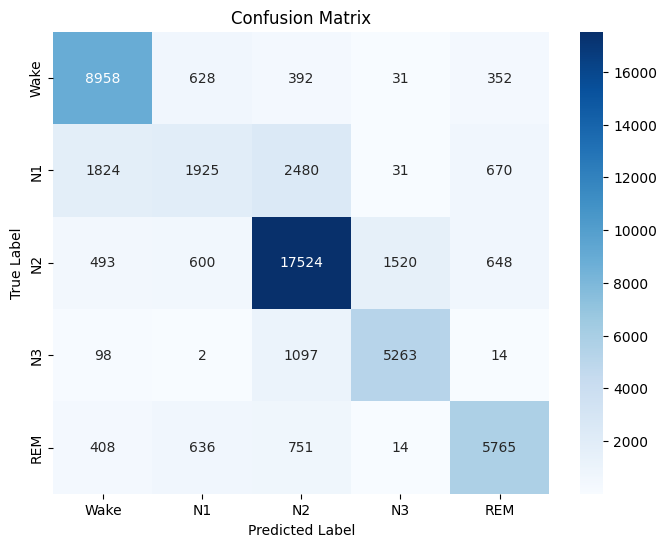

Cohen's Kappa: 0.6701916400271657


In [ ]:
def build_mlp(input_dim, n_classes, dropout_rate=0.3):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(dropout_rate),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(dropout_rate),
        layers.Dense(64, activation='relu'),
        layers.Dense(n_classes, activation='softmax')
    ])
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

input_dim = X_train.shape[1]
model_mlp = build_mlp(input_dim, 5)

early_stop = callbacks.EarlyStopping(patience=15, restore_best_weights=True)
reduce_lr  = callbacks.ReduceLROnPlateau(factor=0.5, patience=5)

start_time = time.time()

history = model_mlp.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=512,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

end_time = time.time()
print(f"Training time: {end_time - start_time:.2f} seconds")

y_pred_probs = model_mlp.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_val

utils.evaluate_model(y_true, y_pred)

print("Cohen's Kappa:", cohen_kappa_score(y_true, y_pred))

## MLP + SE

In [ ]:
def build_mlp_se(input_dim, n_classes, dropout_rate=0.3):
    inputs = layers.Input(shape=(input_dim,))

    x = layers.Dense(256, activation='relu')(inputs)
    x = utils.se_feature_attention(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)

    x = layers.Dense(128, activation='relu')(x)
    x = utils.se_feature_attention(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)

    x = layers.Dense(64, activation='relu')(x)

    outputs = layers.Dense(n_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

Epoch 1/100
446/446 ━━━━━━━━━━━━━━━━━━━━ 15s 26ms/step - accuracy: 0.7158 - loss: 0.7557 - val_accuracy: 0.7281 - val_loss: 0.7159 - learning_rate: 0.0010
Epoch 2/100
446/446 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - accuracy: 0.7571 - loss: 0.6356 - val_accuracy: 0.7416 - val_loss: 0.6837 - learning_rate: 0.0010
Epoch 3/100
446/446 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.7734 - loss: 0.5914 - val_accuracy: 0.7489 - val_loss: 0.6625 - learning_rate: 0.0010
Epoch 4/100
446/446 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.7826 - loss: 0.5641 - val_accuracy: 0.7412 - val_loss: 0.6974 - learning_rate: 0.0010
Epoch 5/100
446/446 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.7904 - loss: 0.5429 - val_accuracy: 0.7497 - val_loss: 0.6746 - learning_rate: 0.0010
Epoch 6/100
446/446 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.7962 - loss: 0.5284 - val_accuracy: 0.7461 - val_loss: 0.6715 - learning_rate: 0.0010
Epoch 7/100
446/446 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.8012

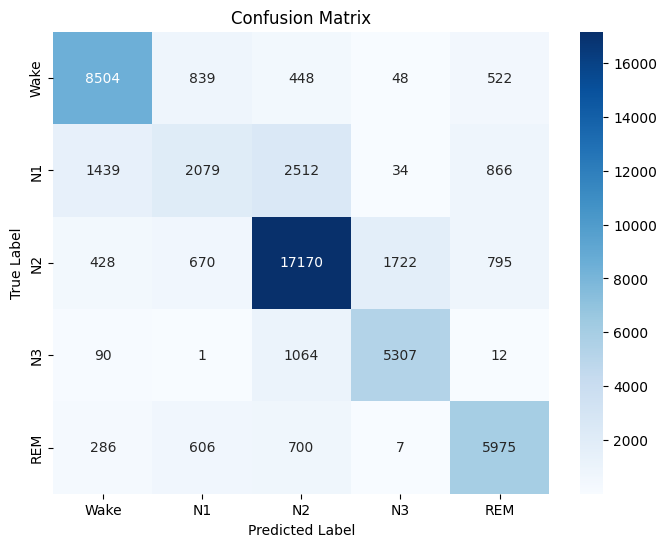

Cohen's Kappa: 0.6611552556314202


In [ ]:
input_dim = X_train.shape[1]

model_mlp = build_mlp_se(input_dim, 5)

early_stop = callbacks.EarlyStopping(patience=15, restore_best_weights=True)
reduce_lr  = callbacks.ReduceLROnPlateau(factor=0.5, patience=5)

history = model_mlp.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=512,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

y_pred_probs = model_mlp.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)

utils.evaluate_model(y_val, y_pred)
print("Cohen's Kappa:", cohen_kappa_score(y_val, y_pred))

## LSTM + Cross Entropy

Epoch 1/50
690/690 ━━━━━━━━━━━━━━━━━━━━ 132s 178ms/step - accuracy: 0.6188 - loss: 1.2059 - val_accuracy: 0.6845 - val_loss: 0.9111 - learning_rate: 0.0010
Epoch 2/50
690/690 ━━━━━━━━━━━━━━━━━━━━ 124s 180ms/step - accuracy: 0.7005 - loss: 0.7905 - val_accuracy: 0.6758 - val_loss: 0.8381 - learning_rate: 0.0010
Epoch 3/50
690/690 ━━━━━━━━━━━━━━━━━━━━ 141s 179ms/step - accuracy: 0.7203 - loss: 0.7071 - val_accuracy: 0.7251 - val_loss: 0.7415 - learning_rate: 0.0010
Epoch 4/50
690/690 ━━━━━━━━━━━━━━━━━━━━ 141s 178ms/step - accuracy: 0.7364 - loss: 0.6652 - val_accuracy: 0.6765 - val_loss: 0.8561 - learning_rate: 0.0010
Epoch 5/50
690/690 ━━━━━━━━━━━━━━━━━━━━ 125s 181ms/step - accuracy: 0.7416 - loss: 0.6407 - val_accuracy: 0.7123 - val_loss: 0.7668 - learning_rate: 0.0010
Epoch 6/50
690/690 ━━━━━━━━━━━━━━━━━━━━ 142s 181ms/step - accuracy: 0.7474 - loss: 0.6229 - val_accuracy: 0.7001 - val_loss: 0.7732 - learning_rate: 0.0010
Epoch 7/50
690/690 ━━━━━━━━━━━━━━━━━━━━ 122s 177ms/step - accura

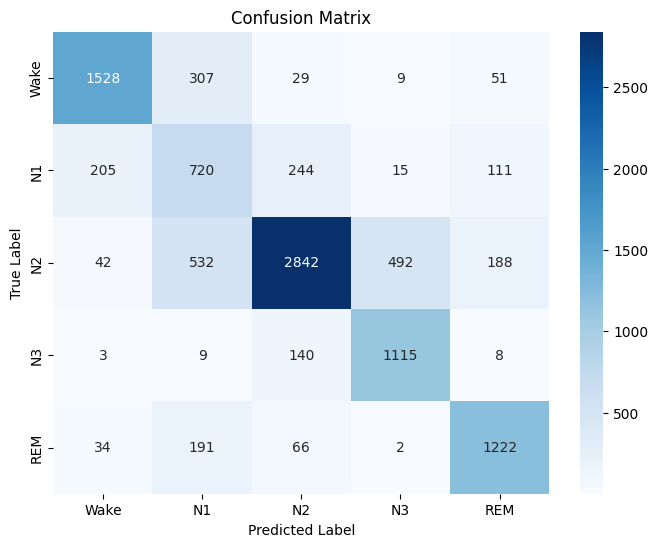

Cohen's Kappa: 0.6542506940969838


In [ ]:
def build_lstm_focal_loss(input_shape, n_classes, units=128, dropout=0.4, recurrent_dropout=0.2):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.LSTM(units, return_sequences=True,
                    dropout=dropout, recurrent_dropout=recurrent_dropout),
        layers.BatchNormalization(),
        layers.LSTM(units//2, dropout=dropout, recurrent_dropout=recurrent_dropout),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu', kernel_regularizer='l2'),
        layers.Dropout(0.2),
        layers.Dense(n_classes, activation='softmax')
    ])
    model.compile(
    optimizer='adam',
    loss=utils.focal_loss(gamma=2.0),
    metrics=['accuracy']
)
    return model

n_features = X_train_seq.shape[2]
input_shape = (X_train_seq.shape[1], n_features)

model = build_lstm_focal_loss(input_shape, 5)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = callbacks.EarlyStopping(patience=15, restore_best_weights=True)
reduce_lr  = callbacks.ReduceLROnPlateau(factor=0.5, patience=5)

start_time = time.time()

history = model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=50,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr]
)

end_time = time.time()
print(f"Training time: {end_time - start_time:.2f} seconds")

y_pred = model.predict(X_val_seq)
y_pred = np.argmax(y_pred, axis=1)
y_true = y_val_seq

utils.evaluate_model(y_true, y_pred)

print("Cohen's Kappa:", cohen_kappa_score(y_true, y_pred))

## LSTM + SE

* best lstm

In [ ]:
def build_lstm_se_focal(input_shape, n_classes, units=128, dropout=0.4, recurrent_dropout=0.2):
    inputs = layers.Input(shape=input_shape)

    # LSTM 1 (return sequences)
    x = layers.LSTM(
        units,
        return_sequences=True,
        dropout=dropout,
        recurrent_dropout=recurrent_dropout
    )(inputs)
    x = layers.BatchNormalization()(x)

    # LSTM 2 (return last hidden state)
    x = layers.LSTM(
        units // 2,
        dropout=dropout,
        recurrent_dropout=recurrent_dropout
    )(x)
    x = layers.BatchNormalization()(x)

    # SE block on final feature vector
    x = utils.se_feature_attention(x)

    # Dense layers
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation='relu', kernel_regularizer='l2')(x)
    x = layers.Dropout(0.2)(x)

    outputs = layers.Dense(n_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    model.compile(
        optimizer='adam',
        loss=utils.focal_loss(gamma=2.0),
        metrics=['accuracy']
    )
    return model

Epoch 1/100
690/690 ━━━━━━━━━━━━━━━━━━━━ 138s 186ms/step - accuracy: 0.6721 - loss: 0.1966 - val_accuracy: 0.7159 - val_loss: 0.0962 - learning_rate: 0.0010
Epoch 2/100
690/690 ━━━━━━━━━━━━━━━━━━━━ 143s 187ms/step - accuracy: 0.7342 - loss: 0.0867 - val_accuracy: 0.7368 - val_loss: 0.0853 - learning_rate: 0.0010
Epoch 3/100
690/690 ━━━━━━━━━━━━━━━━━━━━ 138s 181ms/step - accuracy: 0.7543 - loss: 0.0775 - val_accuracy: 0.7397 - val_loss: 0.0858 - learning_rate: 0.0010
Epoch 4/100
690/690 ━━━━━━━━━━━━━━━━━━━━ 123s 178ms/step - accuracy: 0.7638 - loss: 0.0726 - val_accuracy: 0.7594 - val_loss: 0.0790 - learning_rate: 0.0010
Epoch 5/100
690/690 ━━━━━━━━━━━━━━━━━━━━ 123s 178ms/step - accuracy: 0.7738 - loss: 0.0689 - val_accuracy: 0.7533 - val_loss: 0.0812 - learning_rate: 0.0010
Epoch 6/100
690/690 ━━━━━━━━━━━━━━━━━━━━ 147s 185ms/step - accuracy: 0.7760 - loss: 0.0673 - val_accuracy: 0.7622 - val_loss: 0.0778 - learning_rate: 0.0010
Epoch 7/100
690/690 ━━━━━━━━━━━━━━━━━━━━ 142s 184ms/step -

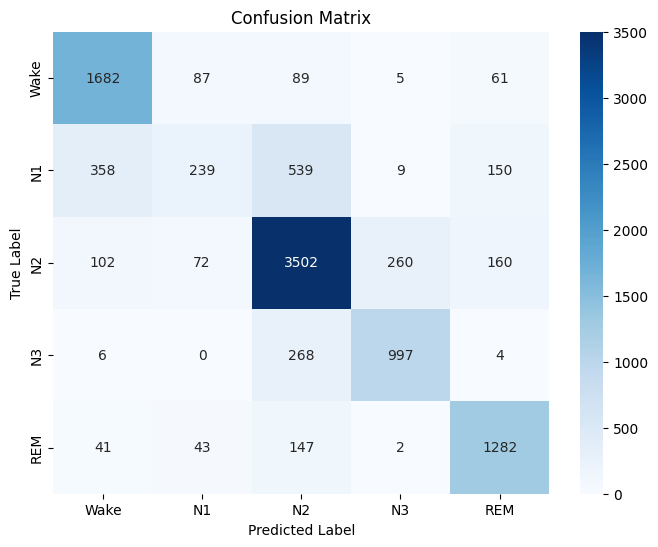

Cohen's Kappa: 0.6744061535982788


In [ ]:
n_features = X_train_seq.shape[2]
input_shape = (X_train_seq.shape[1], n_features)

model_lstm = build_lstm_se_focal(input_shape, 5)

early_stop = callbacks.EarlyStopping(patience=15, restore_best_weights=True)
reduce_lr  = callbacks.ReduceLROnPlateau(factor=0.5, patience=5)

history = model_lstm.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=100,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

y_pred = np.argmax(model_lstm.predict(X_val_seq), axis=1)
utils.evaluate_model(y_val_seq, y_pred)
print("Cohen's Kappa:", cohen_kappa_score(y_val_seq, y_pred))

## 1D-ResNet

* best resnet

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_resnet_feature_model(seq_len, n_features, n_classes=5):

    inp = layers.Input(shape=(seq_len, n_features))

    def conv_block(x, filters):
        shortcut = x

        x = layers.Conv1D(filters, 3, padding='same',
                          kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)

        x = layers.Conv1D(filters, 3, padding='same',
                          kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
        x = layers.BatchNormalization()(x)

        if shortcut.shape[-1] != filters:
            shortcut = layers.Conv1D(filters, 1, padding='same',
                                     kernel_regularizer=tf.keras.regularizers.l2(1e-4))(shortcut)

        x = layers.Add()([x, shortcut])
        x = layers.ReLU()(x)
        x = layers.Dropout(0.2)(x)
        return x

    x = conv_block(inp, 32)
    x = conv_block(x, 64)
    x = conv_block(x, 128)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(n_classes, activation='softmax')(x)

    model = models.Model(inp, out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(3e-4),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=['accuracy']
    )
    return model

Epoch 1/100
690/690 ━━━━━━━━━━━━━━━━━━━━ 57s 70ms/step - accuracy: 0.6028 - loss: 1.0228 - val_accuracy: 0.6299 - val_loss: 0.9792 - learning_rate: 3.0000e-04
Epoch 2/100
690/690 ━━━━━━━━━━━━━━━━━━━━ 81s 69ms/step - accuracy: 0.6909 - loss: 0.8218 - val_accuracy: 0.6901 - val_loss: 0.8509 - learning_rate: 3.0000e-04
Epoch 3/100
690/690 ━━━━━━━━━━━━━━━━━━━━ 47s 69ms/step - accuracy: 0.7176 - loss: 0.7500 - val_accuracy: 0.6726 - val_loss: 0.9092 - learning_rate: 3.0000e-04
Epoch 4/100
690/690 ━━━━━━━━━━━━━━━━━━━━ 47s 68ms/step - accuracy: 0.7355 - loss: 0.7034 - val_accuracy: 0.7106 - val_loss: 0.8196 - learning_rate: 3.0000e-04
Epoch 5/100
690/690 ━━━━━━━━━━━━━━━━━━━━ 50s 72ms/step - accuracy: 0.7465 - loss: 0.6724 - val_accuracy: 0.7125 - val_loss: 0.7941 - learning_rate: 3.0000e-04
Epoch 6/100
690/690 ━━━━━━━━━━━━━━━━━━━━ 47s 69ms/step - accuracy: 0.7544 - loss: 0.6505 - val_accuracy: 0.7139 - val_loss: 0.8104 - learning_rate: 3.0000e-04
Epoch 7/100
690/690 ━━━━━━━━━━━━━━━━━━━━ 47s 6

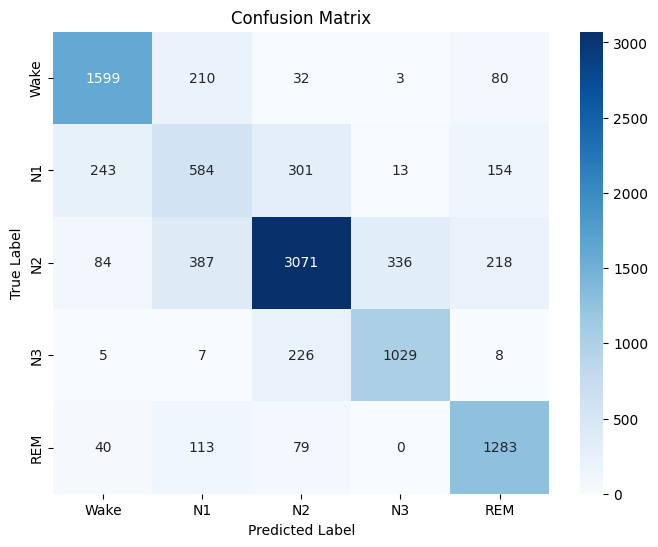

Cohen's Kappa: 0.6669728128340531


In [ ]:
early_stop = callbacks.EarlyStopping(patience=15, restore_best_weights=True)
reduce_lr  = callbacks.ReduceLROnPlateau(factor=0.5, patience=5)

resnet = build_resnet_feature_model(
    seq_len=X_train_seq.shape[1],
    n_features=X_train_seq.shape[2],
    n_classes=5
)

history = resnet.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=100,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


y_pred = np.argmax(resnet.predict(X_val_seq), axis=1)
utils.evaluate_model(y_val_seq, y_pred)
print("Cohen's Kappa:", cohen_kappa_score(y_val_seq, y_pred))

## 1D-ResNet + SE

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_resnet_feature_model(seq_len, n_features, n_classes=5):

    inp = layers.Input(shape=(seq_len, n_features))

    def conv_block(x, filters):
        shortcut = x

        x = layers.Conv1D(filters, 3, padding='same',
                          kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)

        x = layers.Conv1D(filters, 3, padding='same',
                          kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
        x = layers.BatchNormalization()(x)

        if shortcut.shape[-1] != filters:
            shortcut = layers.Conv1D(filters, 1, padding='same',
                                     kernel_regularizer=tf.keras.regularizers.l2(1e-4))(shortcut)

        x = layers.Add()([x, shortcut])
        x = layers.ReLU()(x)

        x = se_channel_attention(x)

        x = layers.Dropout(0.2)(x)
        return x

    x = conv_block(inp, 32)
    x = conv_block(x, 64)
    x = conv_block(x, 128)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.4)(x)

    out = layers.Dense(n_classes, activation='softmax')(x)

    model = models.Model(inp, out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(3e-4),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=['accuracy']
    )
    return model

Epoch 1/100
690/690 ━━━━━━━━━━━━━━━━━━━━ 61s 74ms/step - accuracy: 0.6135 - loss: 1.0020 - val_accuracy: 0.6662 - val_loss: 0.9009 - learning_rate: 3.0000e-04
Epoch 2/100
690/690 ━━━━━━━━━━━━━━━━━━━━ 49s 71ms/step - accuracy: 0.6894 - loss: 0.8213 - val_accuracy: 0.6732 - val_loss: 0.8848 - learning_rate: 3.0000e-04
Epoch 3/100
690/690 ━━━━━━━━━━━━━━━━━━━━ 51s 74ms/step - accuracy: 0.7179 - loss: 0.7482 - val_accuracy: 0.6986 - val_loss: 0.8377 - learning_rate: 3.0000e-04
Epoch 4/100
690/690 ━━━━━━━━━━━━━━━━━━━━ 82s 74ms/step - accuracy: 0.7354 - loss: 0.7036 - val_accuracy: 0.7048 - val_loss: 0.8034 - learning_rate: 3.0000e-04
Epoch 5/100
690/690 ━━━━━━━━━━━━━━━━━━━━ 50s 72ms/step - accuracy: 0.7486 - loss: 0.6714 - val_accuracy: 0.7196 - val_loss: 0.7822 - learning_rate: 3.0000e-04
Epoch 6/100
690/690 ━━━━━━━━━━━━━━━━━━━━ 51s 75ms/step - accuracy: 0.7566 - loss: 0.6474 - val_accuracy: 0.7296 - val_loss: 0.7644 - learning_rate: 3.0000e-04
Epoch 7/100
690/690 ━━━━━━━━━━━━━━━━━━━━ 50s 7

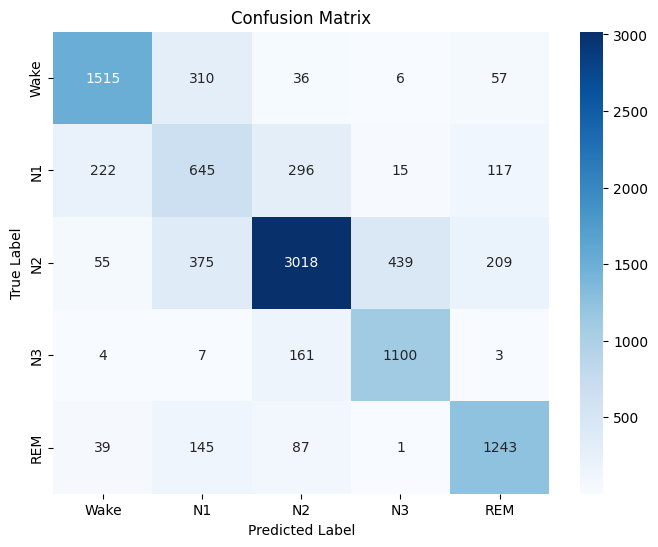

Cohen's Kappa: 0.6629304614481069


In [ ]:
early_stop = callbacks.EarlyStopping(patience=15, restore_best_weights=True)
reduce_lr  = callbacks.ReduceLROnPlateau(factor=0.5, patience=5)

resnet = build_resnet_feature_model(
    seq_len=X_train_seq.shape[1],
    n_features=X_train_seq.shape[2],
    n_classes=5
)

history = resnet.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=100,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


y_pred = np.argmax(resnet.predict(X_val_seq), axis=1)
utils.evaluate_model(y_val_seq, y_pred)
print("Cohen's Kappa:", cohen_kappa_score(y_val_seq, y_pred))